In [1]:
import numpy as np

# Create a vector as a NumPy array
# This could represent a customer: [age, income, spending_score]
customer_vector = np.array([35, 60000, 85])
print(f"Customer vector: {customer_vector}")

# Another vector
# This could represent weights in a simple model
weights = np.array([0.5, 0.25, 1.5])
print(f"Weights vector: {weights}")

# --- Basic Vector Operations ---

# Element-wise addition
sum_vector = customer_vector + weights
print(f"\nVector Addition: {sum_vector}")

# Element-wise subtraction
diff_vector = customer_vector - weights
print(f"Vector Subtraction: {diff_vector}")

# Scalar multiplication (multiplying the entire vector by a single number)
scaled_vector = customer_vector * 2
print(f"Scalar Multiplication: {scaled_vector}")

# --- The Dot Product: The Most Important Operation ---
# The dot product is the sum of the element-wise products of two vectors.
# It's fundamental to calculating weighted sums in neural networks.
# Formula: (a1*b1) + (a2*b2) + (a3*b3) + ...
dot_product = np.dot(customer_vector, weights)

# This calculation (35*0.5 + 60000*0.25 + 85*1.5) could represent the
# final "score" for this customer, as calculated by a simple linear model.
print(f"\nDot Product: {dot_product}")

Customer vector: [   35 60000    85]
Weights vector: [0.5  0.25 1.5 ]

Vector Addition: [3.550000e+01 6.000025e+04 8.650000e+01]
Vector Subtraction: [3.450000e+01 5.999975e+04 8.350000e+01]
Scalar Multiplication: [    70 120000    170]

Dot Product: 15145.0


In [2]:
# A matrix can represent a batch of data.
# 3 customers, each with 2 features: [annual_income, spending_score]
data_batch = np.array([
    [70000, 90],  # Customer 1
    [45000, 40],  # Customer 2
    [120000, 81]  # Customer 3
])

print("--- Data Matrix ---")
print(data_batch)
print(f"Shape of the matrix: {data_batch.shape}") # (3 rows, 2 columns)

# --- Matrix Operations ---

# Transpose: Swaps the rows and columns. This is very useful for
# aligning dimensions for matrix multiplication.
transposed_matrix = data_batch.T
print("\n--- Transposed Matrix ---")
print(transposed_matrix)
print(f"Shape of transposed matrix: {transposed_matrix.shape}") # (2 rows, 3 columns)

--- Data Matrix ---
[[ 70000     90]
 [ 45000     40]
 [120000     81]]
Shape of the matrix: (3, 2)

--- Transposed Matrix ---
[[ 70000  45000 120000]
 [    90     40     81]]
Shape of transposed matrix: (2, 3)


In [3]:
# Let's define a weight matrix for a neural network layer with 2 neurons.
# Each neuron needs a weight for each input feature.
# We have 2 input features (income, spending_score), so we need 2 weights per neuron.
# Neuron 1 weights: [w11, w12]
# Neuron 2 weights: [w21, w22]
# We typically write this as a matrix of shape (2 features, 2 neurons)
# or (2 neurons, 2 features). Let's use the latter.
#
# Shape (num_neurons, num_features) = (2, 2)
# The rule is (m x n) @ (n x p) -> (m x p)
# So we need to multiply (num_neurons, num_features) @ (num_features, num_samples)
# which means we need to multiply our weights by the *transposed* data batch.

# Let's say Neuron 1 is a "high-value customer" detector
# and Neuron 2 is a "low-income, low-spending" detector.
# Shape: (2 neurons, 2 features)
layer_weights = np.array([
    [0.001, 0.5], # Neuron 1 weights (high income, high spending)
    [-0.002, -0.8]  # Neuron 2 weights (penalizes income and spending)
])

# Our data batch has shape (3, 2). The weights have shape (2, 2).
# We can't multiply (2, 2) @ (3, 2). The inner dimensions don't match (2 != 3).
# We need to multiply the weights by the transposed data batch.
# Transposed data batch shape: (2, 3)
# Now we can multiply: (2, 2) @ (2, 3) -> (2, 3)
data_batch_transposed = data_batch.T

# Perform matrix multiplication using the '@' operator (the modern way)
layer_output = layer_weights @ data_batch_transposed

print("--- Matrix Multiplication ---")
print(f"Weights shape: {layer_weights.shape}")
print(f"Transposed data shape: {data_batch_transposed.shape}")
print(f"Output shape: {layer_output.shape}")
print("\nLayer output (results for each neuron on each customer):")
print(layer_output)

# To make the output more readable, let's transpose it back
# so rows are customers and columns are neuron outputs.
print("\nTransposed output (easier to read):")
print(layer_output.T)

--- Matrix Multiplication ---
Weights shape: (2, 2)
Transposed data shape: (2, 3)
Output shape: (2, 3)

Layer output (results for each neuron on each customer):
[[ 115.    65.   160.5]
 [-212.  -122.  -304.8]]

Transposed output (easier to read):
[[ 115.  -212. ]
 [  65.  -122. ]
 [ 160.5 -304.8]]


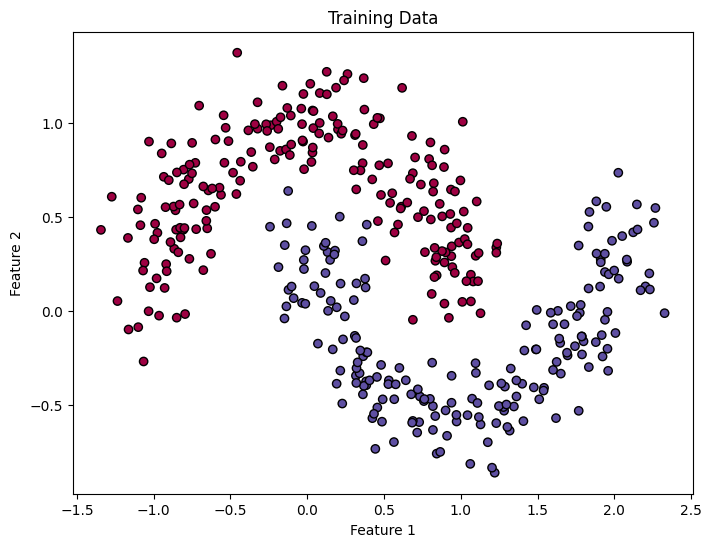

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# ======================================================================
# Step 1: Generate and Prepare Data
# ======================================================================
# make_moons creates two interleaving half-circles. It's a classic
# dataset for testing non-linear classifiers.
X, y = make_moons(n_samples=500, noise=0.15, random_state=42)

# Reshape y to be a column vector (500, 1) instead of a flat array (500,)
# This makes matrix math easier later on.
y = y.reshape(-1, 1)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Visualize the training data
plt.figure(figsize=(8, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train.ravel(), cmap=plt.cm.Spectral, edgecolors='k')
plt.title("Training Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# Generate data
X, y = make_moons(n_samples=500, noise=0.15, random_state=42)
y = y.reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def initialize_parameters(input_size, hidden_size, output_size):
    W1 = np.random.randn(input_size, hidden_size) * 0.01
    b1 = np.zeros((1, hidden_size))  # FIXED: Use tuple
    
    W2 = np.random.randn(hidden_size, output_size) * 0.01  # FIXED: Correct shape
    b2 = np.zeros((1, output_size))  # FIXED: Use tuple
    
    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -250, 250)))  # Added clipping for stability

def forward_pass(X, parameters):
    W1, b1 = parameters["W1"], parameters["b1"]
    W2, b2 = parameters["W2"], parameters["b2"]
    
    Z1 = np.dot(X, W1) + b1
    A1 = np.tanh(Z1)
    
    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)
    
    cache = {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}
    return A2, cache

def compute_loss(A2, Y):
    m = Y.shape[0]
    loss = -1/m * np.sum(Y * np.log(A2 + 1e-8) + (1 - Y) * np.log(1 - A2 + 1e-8))
    return loss

def backward_pass(parameters, cache, X, Y):
    m = X.shape[0]
    W2 = parameters["W2"]
    A1, A2 = cache["A1"], cache["A2"]
    
    dZ2 = A2 - Y
    dW2 = 1/m * np.dot(A1.T, dZ2)
    db2 = 1/m * np.sum(dZ2, axis=0, keepdims=True)
    
    dZ1 = np.dot(dZ2, W2.T) * (1 - np.power(A1, 2))
    dW1 = 1/m * np.dot(X.T, dZ1)
    db1 = 1/m * np.sum(dZ1, axis=0, keepdims=True)
    
    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}

def update_parameters(parameters, grads, learning_rate):
    for key in parameters:
        parameters[key] = parameters[key] - learning_rate * grads["d" + key]
    return parameters

def train_model(X, Y, hidden_size, epochs=10000, learning_rate=1.2):
    input_size, output_size = X.shape[1], Y.shape[1]
    parameters = initialize_parameters(input_size, hidden_size, output_size)
    
    for i in range(epochs):
        A2, cache = forward_pass(X, parameters)
        loss = compute_loss(A2, Y)
        grads = backward_pass(parameters, cache, X, Y)
        parameters = update_parameters(parameters, grads, learning_rate)
        
        if i % 1000 == 0:
            print(f"Loss after epoch {i}: {loss:.4f}")
    
    return parameters

# Train the model
trained_parameters = train_model(X_train, y_train, hidden_size=4)

def predict(parameters, X):
    A2, _ = forward_pass(X, parameters)
    return (A2 > 0.5).astype(int)

# Test the model
y_pred_test = predict(trained_parameters, X_test)
accuracy = np.mean(y_pred_test == y_test) * 100
print(f"\nAccuracy on the test set: {accuracy:.2f}%")

Loss after epoch 0: 0.6932
Loss after epoch 1000: 0.0358
Loss after epoch 2000: 0.0133
Loss after epoch 3000: 0.0102
Loss after epoch 4000: 0.0088
Loss after epoch 5000: 0.0078
Loss after epoch 6000: 0.0071
Loss after epoch 7000: 0.0064
Loss after epoch 8000: 0.0058
Loss after epoch 9000: 0.0052

Accuracy on the test set: 100.00%
